#  Practical Homework 4 Extension: Joining Historical Redlining Data

This notebook attaches the 1936 HOLC (Home Owners' Loan Corporation) redlining grades to the census tracts used in our Practical Homework 4 analysis. The original research question asked whether Seattle's housing market still tracks the boundaries drawn by 1930s redlining. The PHW4 modeling found that PC1 combines housing size, value, and racial composition into a single axis. This join produces the data needed to test that axis against the actual historical grades.

Data sources:

- HOLC grade polygons for Seattle (1936) from the Mapping Inequality project, University of Richmond. Downloaded from https://dsl.richmond.edu/panorama/redlining/static/citiesData/WASeattle1936/geojson.json and saved as holc_seattle.geojson. Citation: Nelson, R. K., Winling, L, et al. (2023). Mapping Inequality: Redlining in New Deal America. Digital Scholarship Lab. https://dsl.richmond.edu/panorama/redlining.
- 2024 TIGER/Line census tract shapefile for Washington from the Census Bureau, the same file used in the PHW4 preprocessing spatial join.
- seattle_parcels_with_tract.csv from the PHW4 preprocessing notebook, used here only to identify which tracts are in our study area.

The output is one CSV, seattle_tracts_holc.csv, with one row per tract. It joins to the modeling dataframe on GEOID in one line.

Note on method: computing the overlap between tract polygons and HOLC polygons uses geopandas, which is outside the ISL toolkit. Same as in preprocessing, this is a one-time data preparation step. All modeling stays within the methods covered in lecture.

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

## Load the inputs

Update the two paths below to wherever the files live on your machine. The HOLC GeoJSON needs to be downloaded once from the URL above.

In [3]:
import os
import urllib.request

# 1936 HOLC polygons for Seattle from Mapping Inequality.
# Download once if the file is not already next to this notebook.
holc_url = 'https://dsl.richmond.edu/panorama/redlining/static/citiesData/WASeattle1936/geojson.json'
if not os.path.exists('holc_seattle.geojson'):
    urllib.request.urlretrieve(holc_url, 'holc_seattle.geojson')
    print('downloaded holc_seattle.geojson')

holc = gpd.read_file('holc_seattle.geojson')

# same WA tract shapefile used in the preprocessing spatial join
tract_shape = gpd.read_file('/Users/jackneton/Downloads/wa_census_tract_shape.zip')

# parcel data from preprocessing, used to identify our study-area tracts
parcels = pd.read_csv('seattle_parcels_with_tract.csv', dtype={'GEOID': str})

print(holc.shape, tract_shape.shape, parcels.shape)

Skipping field label_coords: unsupported OGR type: 3


(62, 14) (1784, 14) (193074, 20)


/var/folders/nf/xj9w2p992vzfzsk5h40k9hb40000gn/T/ipykernel_5612/1576681665.py:17: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  parcels = pd.read_csv('seattle_parcels_with_tract.csv', dtype={'GEOID': str})


In [4]:
# HOLC features carry a letter grade A through D. Keep only graded polygons.
print(holc['grade'].value_counts(dropna=False))
holc = holc[holc['grade'].isin(['A', 'B', 'C', 'D'])].copy()

grade
B       19
C       18
A       12
D       11
None     2
Name: count, dtype: int64


## Restrict tracts to the study area

The shapefile covers all of Washington. Keep King County (COUNTYFP 033) and then only the tracts that actually appear in our parcel data.

In [5]:
tracts = tract_shape[tract_shape['COUNTYFP'] == '033'].copy()
study_geoids = set(parcels['GEOID'].unique())
tracts = tracts[tracts['GEOID'].isin(study_geoids)].copy()
print('tracts in study area:', len(tracts), 'of', len(study_geoids), 'in parcel data')

tracts in study area: 181 of 181 in parcel data


## Compute percent area overlap with each HOLC grade

Both layers are reprojected to an equal-area CRS (EPSG:5070, Albers) so polygon areas are meaningful, then intersected. For each tract, the area falling under each grade is divided by the total tract area, giving four columns pct_holc_A through pct_holc_D. Tracts outside the 1936 mapped area get zeros.

In [6]:
tracts_ea = tracts.to_crs(epsg=5070)
holc_ea = holc.to_crs(epsg=5070)

tracts_ea['tract_area'] = tracts_ea.geometry.area

# intersect every tract with every HOLC polygon it touches
inter = gpd.overlay(tracts_ea[['GEOID', 'tract_area', 'geometry']],
                    holc_ea[['grade', 'geometry']],
                    how='intersection')
inter['piece_area'] = inter.geometry.area

# share of each tract's area in each grade
overlap = (inter.groupby(['GEOID', 'grade'])['piece_area'].sum()
                .unstack(fill_value=0))
overlap = overlap.reindex(columns=['A', 'B', 'C', 'D'], fill_value=0)
overlap = overlap.div(tracts_ea.set_index('GEOID')['tract_area'], axis=0).fillna(0)
overlap.columns = ['pct_holc_' + g for g in ['A', 'B', 'C', 'D']]

# bring in every study tract, including ones with no HOLC coverage at all
holc_tract = (tracts_ea[['GEOID']].set_index('GEOID')
              .join(overlap).fillna(0).reset_index())
holc_tract.head()

,GEOID,pct_holc_A,pct_holc_B,pct_holc_C,pct_holc_D
0,53033005304,0.00000,4.483842e-01,0.000000,0.000000
1,53033005901,0.00000,1.365832e-01,0.284780,0.000000
2,53033005401,0.00000,3.948537e-07,0.030135,0.131897
3,53033010102,0.03148,1.978415e-01,0.171302,0.000000
4,53033000602,0.00000,0.000000e+00,0.000000,0.000000


## Derive summary columns

Three derived columns for modeling:

- pct_holc_graded: share of the tract inside the 1936 mapped area (sum of the four grade shares).
- holc_dominant_grade: the grade covering the largest share of the tract, or 'ungraded' if the tract has no overlap with the 1936 map. The coverage share is kept alongside so the modeler can apply a stricter cutoff if wanted.
- holc_grade_score: area-weighted mean grade over the graded portion, coding A=1 through D=4. This construct is taken from the Historic Redlining Score developed by Meier and Mitchell, who overlaid the HOLC maps with census tracts for 142 US cities and scored each tract by the area-weighted proportion of each grade, with A coded 1 through D coded 4 (Meier and Mitchell 2021, https://doi.org/10.3886/E141121V2). We compute the same quantity for our 181 study tracts rather than using their published dataset so the score comes from the same tract boundaries and overlap calculation as the grade share columns. It gives a continuous redlining severity score for boxplots and correlations against the principal component scores. NaN where there is no coverage.

In [7]:
grade_cols = ['pct_holc_A', 'pct_holc_B', 'pct_holc_C', 'pct_holc_D']
holc_tract['pct_holc_graded'] = holc_tract[grade_cols].sum(axis=1)

dominant = holc_tract[grade_cols].idxmax(axis=1).str.replace('pct_holc_', '')
holc_tract['holc_dominant_grade'] = np.where(holc_tract['pct_holc_graded'] > 0,
                                             dominant, 'ungraded')

# Historic Redlining Score: area-weighted mean of the HOLC grades with
# A=1, B=2, C=3, D=4, following Meier and Mitchell (2021), Historic
# Redlining Scores for 2010 and 2020 US Census Tracts, ICPSR,
# https://doi.org/10.3886/E141121V2
weights = np.array([1, 2, 3, 4])
weighted = (holc_tract[grade_cols] * weights).sum(axis=1)
holc_tract['holc_grade_score'] = np.where(holc_tract['pct_holc_graded'] > 0,
                                          weighted / holc_tract['pct_holc_graded'],
                                          np.nan)

print(holc_tract['holc_dominant_grade'].value_counts())
print('tracts with any 1936 coverage:', (holc_tract['pct_holc_graded'] > 0).sum(),
      'of', len(holc_tract))
holc_tract['pct_holc_graded'].describe()

holc_dominant_grade
B           61
C           46
ungraded    40
D           28
A            6
Name: count, dtype: int64
tracts with any 1936 coverage: 141 of 181


count    181.000000
mean       0.504707
std        0.410089
min        0.000000
25%        0.003363
50%        0.547622
75%        0.959687
max        1.000000
Name: pct_holc_graded, dtype: float64

## Map check

Visual check: tracts colored by dominant grade next to the raw HOLC polygons. The graded tracts reproduce the shape of the 1936 map.

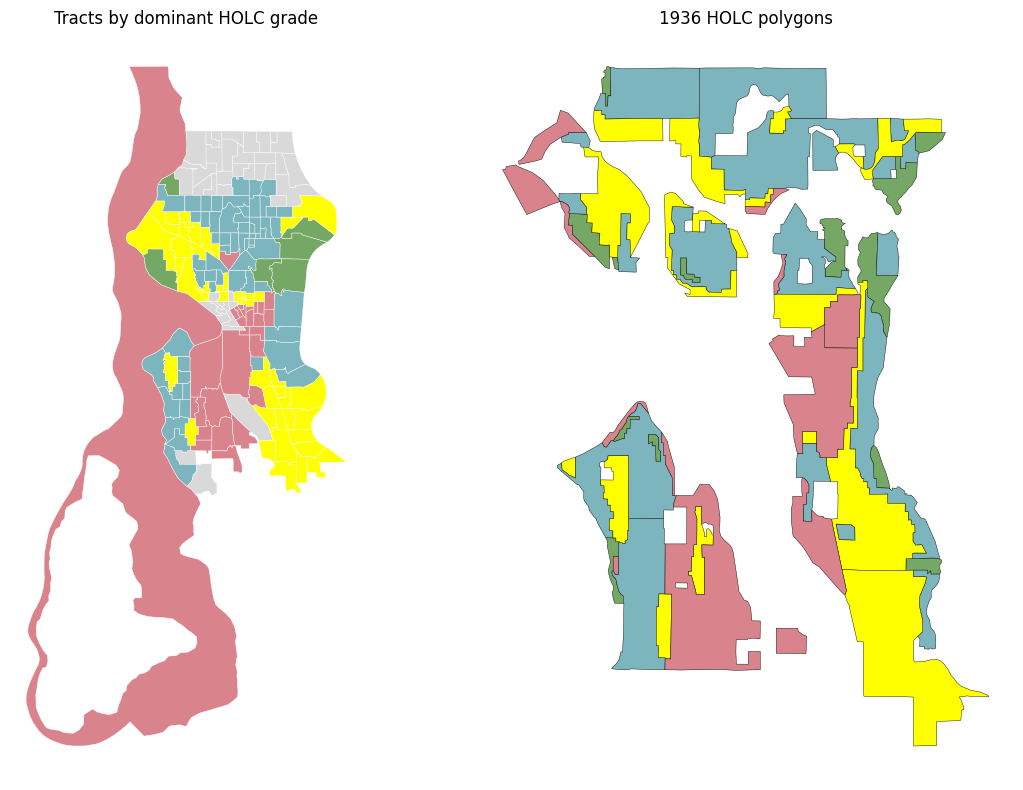

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

plot_df = tracts.merge(holc_tract, on='GEOID')
grade_colors = {'A': '#76a865', 'B': '#7cb5bd', 'C': '#ffff00',
                'D': '#d9838d', 'ungraded': '#d9d9d9'}
plot_df['color'] = plot_df['holc_dominant_grade'].map(grade_colors)
plot_df.plot(ax=axes[0], color=plot_df['color'], edgecolor='white', linewidth=0.3)
axes[0].set_title('Tracts by dominant HOLC grade')
axes[0].set_axis_off()

holc.plot(ax=axes[1], color=holc['grade'].map(grade_colors),
          edgecolor='black', linewidth=0.3)
axes[1].set_title('1936 HOLC polygons')
axes[1].set_axis_off()
plt.tight_layout()
plt.show()

The HOLC grades rank perceived mortgage lending risk: A (green) was "best," B (blue) "still desirable," C (yellow) "definitely declining," and D (red) "hazardous." D areas were the ones outlined in red, which is where the term redlining comes from, and the grading was driven heavily by the racial and immigrant composition of the neighborhoods, not just housing condition.

The left panel shows our 181 modern census tracts, each filled with the color of its dominant 1936 HOLC grade, while the right panel shows the original 1936 HOLC polygons in their own boundaries. Comparing the two tells us how much of the historical grading survives the translation onto modern tract geography: where the panels agree, a tract-level redlining variable is a faithful stand-in for the original map, and where they diverge, the tract boundaries are blending or distorting the historical signal.

The two panels line up well. The blue band of B tracts across north central Seattle, the green A pockets in the northeast and around the Montlake and Madison Park area, the yellow C bands on the city edges, and the concentration of red D tracts through the Central District, the International District, and along the Duwamish industrial corridor in the south all reproduce the structure of the 1936 map on the right. The grey ungraded tracts at the far north and far south are areas Seattle annexed after the HOLC survey was drawn, so having no grade there is correct, not missing data.

One artifact needs flagging. The large red shape wrapping the western and southern shoreline is a tract that is almost entirely water. Its area is dominated by Puget Sound, but a thin sliver of shoreline overlaps a D polygon, and since holc_dominant_grade is assigned whenever coverage is greater than zero, the whole tract renders as D. Its pct_holc_graded value is tiny, which is exactly the case the coverage column exists for. Any analysis using dominant grade should either filter on pct_holc_graded or treat low coverage tracts separately, otherwise this one tract would carry a D label backed by almost no actual 1936 area. The same caution applies to a few partially graded edge tracts where the dominant grade rests on a small share of the tract.

The left panel also draws full tract polygons including their water area, which is why the shapes look inflated relative to the HOLC polygons. That is a rendering matter only; the overlap percentages are computed against total tract area, so water heavy tracts naturally show low pct_holc_graded as well.

Even before any modeling, the visualization shows a clear trend: the grades are not scattered across the city, they form large contiguous zones. The north end is almost entirely A and B, the A pockets hug the waterfront residential areas in the northeast and east, and C and D dominate the central and southern parts of the city, with D following the Central District, the International District, and the Duwamish industrial corridor. The spatial contiguity also matters for interpretation: because the grades cluster geographically, any alignment between modern tract clusters and HOLC grades will partly reflect neighboring tracts resembling each other, so agreement should be read as consistent with persistence of the 1936 boundaries rather than proof of a causal relationship.

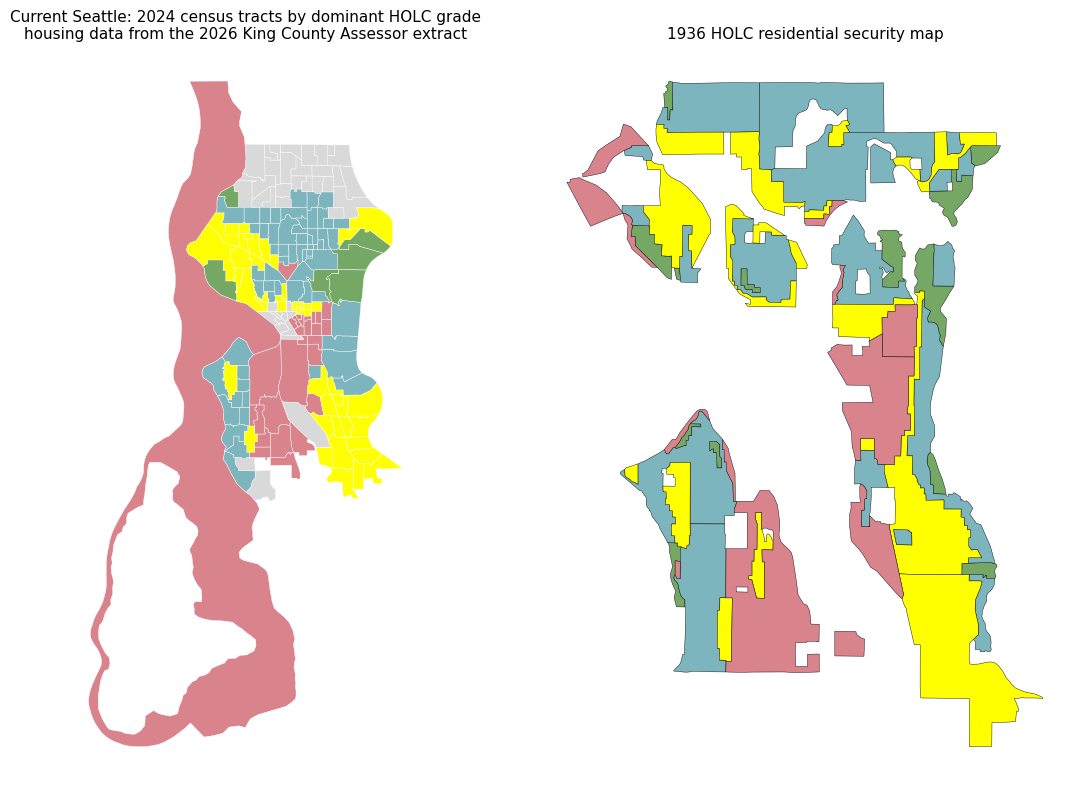

In [9]:
# Same map as above with clearer titles. The left panel is present-day
# Seattle geography, the right panel is the historical map.

# year of the King County Assessor extract behind seattle_parcels_with_tract.csv
housing_data_year = '2026'  # BillYr in EXTR_RPAcct_NoName.csv is 2026 for all 739,488 accounts

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

plot_df = tracts.merge(holc_tract, on='GEOID')
grade_colors = {'A': '#76a865', 'B': '#7cb5bd', 'C': '#ffff00',
                'D': '#d9838d', 'ungraded': '#d9d9d9'}
plot_df['color'] = plot_df['holc_dominant_grade'].map(grade_colors)
plot_df.plot(ax=axes[0], color=plot_df['color'], edgecolor='white', linewidth=0.3)
axes[0].set_title('Current Seattle: 2024 census tracts by dominant HOLC grade\n'
                  'housing data from the ' + housing_data_year
                  + ' King County Assessor extract', fontsize=11)
axes[0].set_axis_off()

holc.plot(ax=axes[1], color=holc['grade'].map(grade_colors),
          edgecolor='black', linewidth=0.3)
axes[1].set_title('1936 HOLC residential security map', fontsize=11)
axes[1].set_axis_off()
plt.tight_layout()
plt.show()

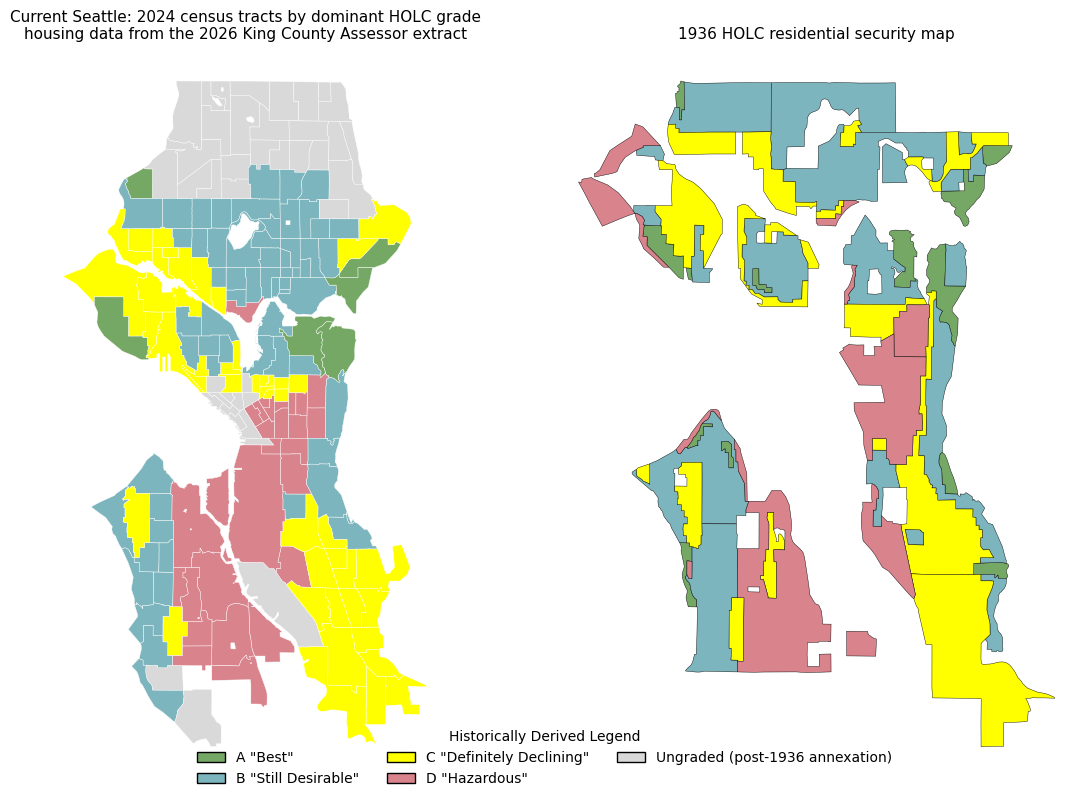

In [10]:
# Redraw with water removed from the tract polygons

# Download water area layer for King County
water_url = ('https://www2.census.gov/geo/tiger/TIGER2024/AREAWATER/' 
             'tl_2024_53033_areawater.zip')
if not os.path.exists('tl_2024_53033_areawater.zip'):
    urllib.request.urlretrieve(water_url, 'tl_2024_53033_areawater.zip')
    print('downloaded tl_2024_53033_areawater.zip')

water = gpd.read_file('tl_2024_53033_areawater.zip').to_crs(plot_df.crs)

# subtract the water polygons from the tract polygons
plot_land = gpd.overlay(plot_df, water[['geometry']], how='difference')

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

plot_land.plot(ax=axes[0], color=plot_land['color'], edgecolor='white', linewidth=0.3)
axes[0].set_title('Current Seattle: 2024 census tracts by dominant HOLC grade\n'
                  'housing data from the ' + housing_data_year
                  + ' King County Assessor extract', fontsize=11)
axes[0].set_axis_off()

holc.plot(ax=axes[1], color=holc['grade'].map(grade_colors),
          edgecolor='black', linewidth=0.3)
axes[1].set_title('1936 HOLC residential security map', fontsize=11)
axes[1].set_axis_off()

# legend for the grade colors, shared by both panels
from matplotlib.patches import Patch
grade_labels = {'A': 'A "Best"', 'B': 'B "Still Desirable"',
                'C': 'C "Definitely Declining"', 'D': 'D "Hazardous"',
                'ungraded': 'Ungraded (post-1936 annexation)'}
handles = [Patch(facecolor=grade_colors[g], edgecolor='black', label=grade_labels[g])
           for g in ['A', 'B', 'C', 'D', 'ungraded']]
fig.legend(handles=handles, title='Historically Derived Legend',
           loc='lower center', ncol=3, frameon=False)

plt.tight_layout()
plt.show()

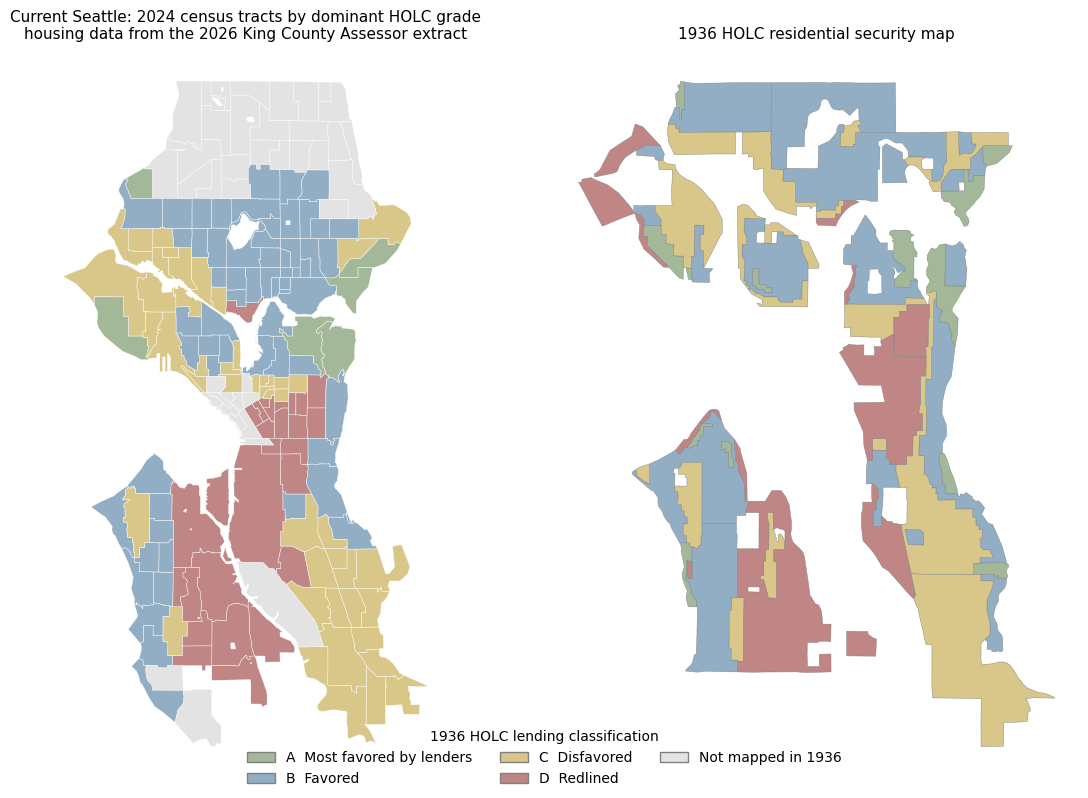

In [11]:
# Final presentation version: muted palette and neutral labels. The
# original HOLC category names stay quoted in the commentary above;
# the figure itself uses descriptive lender-behavior language.

soft_colors = {'A': '#a3b899', 'B': '#92aec4', 'C': '#d9c789',
               'D': '#c08585', 'ungraded': '#e3e3e3'}
soft_labels = {'A': 'A  Most favored by lenders', 'B': 'B  Favored',
               'C': 'C  Disfavored', 'D': 'D  Redlined',
               'ungraded': 'Not mapped in 1936'}

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

plot_land.plot(ax=axes[0],
               color=plot_land['holc_dominant_grade'].map(soft_colors),
               edgecolor='white', linewidth=0.3)
axes[0].set_title('Current Seattle: 2024 census tracts by dominant HOLC grade\n'
                  'housing data from the ' + housing_data_year
                  + ' King County Assessor extract', fontsize=11)
axes[0].set_axis_off()

holc.plot(ax=axes[1], color=holc['grade'].map(soft_colors),
          edgecolor='gray', linewidth=0.3)
axes[1].set_title('1936 HOLC residential security map', fontsize=11)
axes[1].set_axis_off()

handles = [Patch(facecolor=soft_colors[g], edgecolor='gray', label=soft_labels[g])
           for g in ['A', 'B', 'C', 'D', 'ungraded']]
fig.legend(handles=handles, title='1936 HOLC lending classification',
           loc='lower center', ncol=3, frameon=False)

plt.tight_layout()
plt.show()

## Save the output

In [12]:
holc_tract.to_csv('seattle_tracts_holc.csv', index=False)
print('wrote seattle_tracts_holc.csv', holc_tract.shape)

wrote seattle_tracts_holc.csv (181, 8)
